## 5.1.3 Model 3: XGBoost Regressor

Gradient-boosted trees on the unscaled feature set — tree-based models don't need feature scaling. Target is `price`, already log-transformed upstream (Section 3.6), so all metrics below are computed on the log scale unless explicitly converted back to Ringgit (RM) with `np.exp`.

In [24]:
# 5.1.3 Model 3: XGBoost Regressor
# Trained on X_train.csv (unscaled) since tree-based models don't need feature scaling.

import pandas as pd
import numpy as np
import xgboost as xgb
import joblib
import json
from sklearn.model_selection import GridSearchCV
import sys, os

sys.path.append(os.path.dirname(os.path.abspath('__file__')))
from model_utils import evaluate_model, cross_validate_model

MODELLING_DIR = os.path.join("..", "data", "modelling")
MODEL_DIR = os.path.join("..", "models")
os.makedirs(MODEL_DIR, exist_ok=True)

X_train = pd.read_csv(os.path.join(MODELLING_DIR, "X_train.csv"))
X_test = pd.read_csv(os.path.join(MODELLING_DIR, "X_test.csv"))

# price is already log-transformed in the CSV (see Section 3.6) — read as-is
y_train = pd.read_csv(os.path.join(MODELLING_DIR, "y_train.csv"))["price"]
y_test = pd.read_csv(os.path.join(MODELLING_DIR, "y_test.csv"))["price"]

print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")

X_train: (3004, 51) | X_test: (751, 51)


### Hyperparameter Tuning

**Baseline grid search (below, for reference)** covered `n_estimators`, `max_depth`, `learning_rate`, `subsample` only. It picked `max_depth=4, n_estimators=400` and scored well in CV (log-RMSE 0.25), but the fitted model showed a large train/test gap (Train R² 0.957 vs Test R² 0.750, 5-fold CV R² 0.711) — a classic overfitting signature for boosted trees: the search space had no regularization knobs, so the model was free to memorize training rows.

**Fixed below:** add `min_child_weight`, `gamma`, `reg_alpha`, `reg_lambda`, and `colsample_bytree` to the search, and switch to `RandomizedSearchCV` since the expanded grid is too large to search exhaustively. Also add early stopping on a held-out validation split so `n_estimators` self-tunes per candidate instead of being swept as a fixed grid value.

In [25]:
param_grid = {
    "n_estimators": [200, 400],
    "max_depth": [4, 6],
    "learning_rate": [0.05, 0.1],
    "subsample": [0.8, 1.0],
}

grid_search = GridSearchCV(
    xgb.XGBRegressor(random_state=42, objective="reg:squarederror"),
    param_grid,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1,
)
grid_search.fit(X_train, y_train)

print("Best params:", grid_search.best_params_)
print(f"Best CV score (log-scale RMSE): {-grid_search.best_score_:.4f}")

# save tuning result for reference/reproducibility
with open(os.path.join(MODEL_DIR, "xgboost_best_params.json"), "w") as f:
    json.dump(grid_search.best_params_, f, indent=2)

Best params: {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 400, 'subsample': 0.8}
Best CV score (log-scale RMSE): 0.2516


#### Expanded search with regularization + early stopping

In [26]:
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from scipy.stats import randint, uniform

# Held-out split from the training set for early stopping (X_test stays untouched until final eval)
X_fit, X_val, y_fit, y_val = train_test_split(X_train, y_train, test_size=0.15, random_state=42)

param_distributions = {
    "n_estimators": randint(300, 900),
    "max_depth": randint(3, 7),
    "learning_rate": uniform(0.02, 0.13),        # ~0.02-0.15
    "subsample": uniform(0.6, 0.4),               # ~0.6-1.0
    "colsample_bytree": uniform(0.6, 0.4),        # ~0.6-1.0
    "min_child_weight": randint(1, 10),
    "gamma": uniform(0, 0.5),
    "reg_alpha": uniform(0, 2.0),
    "reg_lambda": uniform(0.5, 3.5),               # ~0.5-4.0
}

base_estimator = xgb.XGBRegressor(
    random_state=42,
    objective="reg:squarederror",
    eval_metric="rmse",
    early_stopping_rounds=30,
)

random_search = RandomizedSearchCV(
    base_estimator,
    param_distributions=param_distributions,
    n_iter=60,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1,
    random_state=42,
    verbose=1,
)

# eval_set needed for early stopping — passed via fit_params
random_search.fit(X_fit, y_fit, eval_set=[(X_val, y_val)], verbose=False)

print("Best params:", random_search.best_params_)
print(f"Best CV score (log-scale RMSE): {-random_search.best_score_:.4f}")

with open(os.path.join(MODEL_DIR, "xgboost_best_params.json"), "w") as f:
    json.dump(random_search.best_params_, f, indent=2)

Fitting 5 folds for each of 60 candidates, totalling 300 fits
Best params: {'colsample_bytree': np.float64(0.8363333042276043), 'gamma': np.float64(0.015250124969524714), 'learning_rate': np.float64(0.024855264537397875), 'max_depth': 4, 'min_child_weight': 6, 'n_estimators': 743, 'reg_alpha': np.float64(0.6533024835920818), 'reg_lambda': np.float64(3.3975415132565603), 'subsample': np.float64(0.7086171663278967)}
Best CV score (log-scale RMSE): 0.2593


> **Tuning notes / things worth trying next if the gap is still large:**
> - Drop `max_depth` search ceiling to 5 if Test R² doesn't close the gap — shallower trees regularize more directly than L1/L2 alone.
> - If `State_*` / `PropertyType_*` one-hot columns dominate importance (they do, per the feature-importance table below), consider target encoding instead of one-hot — it can reduce the tree's tendency to split on rare state/property-type combinations.
> - Try `n_iter=100+` for `RandomizedSearchCV` if you have compute budget; 60 is a reasonable starting point, not a ceiling.

In [27]:
# Retrain on the full X_train (not just X_fit) using the tuned params found above,
# with early stopping against the same validation split to pick the right n_estimators.
best_params = {k: v for k, v in random_search.best_params_.items()}

model = xgb.XGBRegressor(
    **best_params,
    random_state=42,
    objective="reg:squarederror",
    eval_metric="rmse",
    early_stopping_rounds=30,
)
model.fit(X_fit, y_fit, eval_set=[(X_val, y_val)], verbose=False)
print(f"Model trained. Best iteration: {model.best_iteration}")


Model trained. Best iteration: 742


In [28]:
# model = xgb.XGBRegressor(**grid_search.best_params_, random_state=42, objective="reg:squarederror")
# model.fit(X_train, y_train)
# print("Model trained.")

### Evaluation Metrics

Same `evaluate_model` helper as the baseline run — compare Train vs Test R² here against the 0.957 / 0.750 baseline gap to check whether regularization actually helped, not just whether CV score improved.

In [29]:
train_metrics = evaluate_model(model, X_train, y_train, label="Train")
print()
test_metrics = evaluate_model(model, X_test, y_test, label="Test")

# save metrics for report reference
with open(os.path.join(MODEL_DIR, "xgboost_metrics.json"), "w") as f:
    json.dump({"train": train_metrics, "test": test_metrics}, f, indent=2)

Train RMSE:  RM 133,343  (38.1% of median price)
Train MAE:   RM 64,679
Train MAPE:  15.8%
Train R2:    0.8346

Test RMSE:  RM 170,507  (47.4% of median price)
Test MAE:   RM 81,720
Test MAPE:  17.5%
Test R2:    0.7359


### 5-Fold Cross-Validation

In [30]:
cv_results = cross_validate_model(
    xgb.XGBRegressor(**grid_search.best_params_, random_state=42, objective="reg:squarederror"),
    X_train, y_train, n_splits=5,
)

5-fold CV (mean +/- std):
  RMSE:  RM 174,354 +/- 27,923  (49.6% of median price)
  MAE:   RM 78,561 +/- 4,985
  MAPE:  18.8% +/- 0.8%
  R2:    0.7113 +/- 0.0511


### Feature Importance

In [31]:
importance_table = pd.Series(model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print("Top 15 features by importance:")
print(importance_table.head(15))

Top 15 features by importance:
PropertyType_Condominium          0.109962
Parking Lot                       0.105251
Has_Gymnasium                     0.078833
Property Size                     0.078806
Has_Security                      0.070311
PropertyType_Service_Residence    0.061250
PropertyType_Flat                 0.054661
Has_Swimming_Pool                 0.054015
Property_Age_Missing              0.043430
State_Penang                      0.041642
State_Selangor                    0.033526
Bathroom                          0.033421
Parking_Lot_Missing               0.018846
State_Melaka                      0.011924
Total_Units_Missing               0.011571
dtype: float32


### Save Model

In [32]:
model_path = os.path.join(MODEL_DIR, "xgboost_model.pkl")
joblib.dump(model, model_path)
print(f"Model saved to {model_path}")

Model saved to ..\models\xgboost_model.pkl


### Demo: Reload & Predict on a Sample Row

In [33]:
# Demo: reload the saved model and predict on an existing test row
import joblib
model = joblib.load(os.path.join(MODEL_DIR, "xgboost_model.pkl"))

sample = X_test.iloc[[0]]           # first row of X_test as a stand-in example
preds_log = model.predict(sample)
preds_rm = np.exp(preds_log)

print(f"Predicted price: RM {preds_rm[0]:,.0f}")
print(f"Actual price:    RM {np.exp(y_test.iloc[0]):,.0f}")

Predicted price: RM 359,526
Actual price:    RM 390,000


### Residual Analysis

Plots residuals (actual − predicted, in RM) on the test set to see where the model struggles most — e.g. underpricing high-end listings, or systematic bias in one price band.

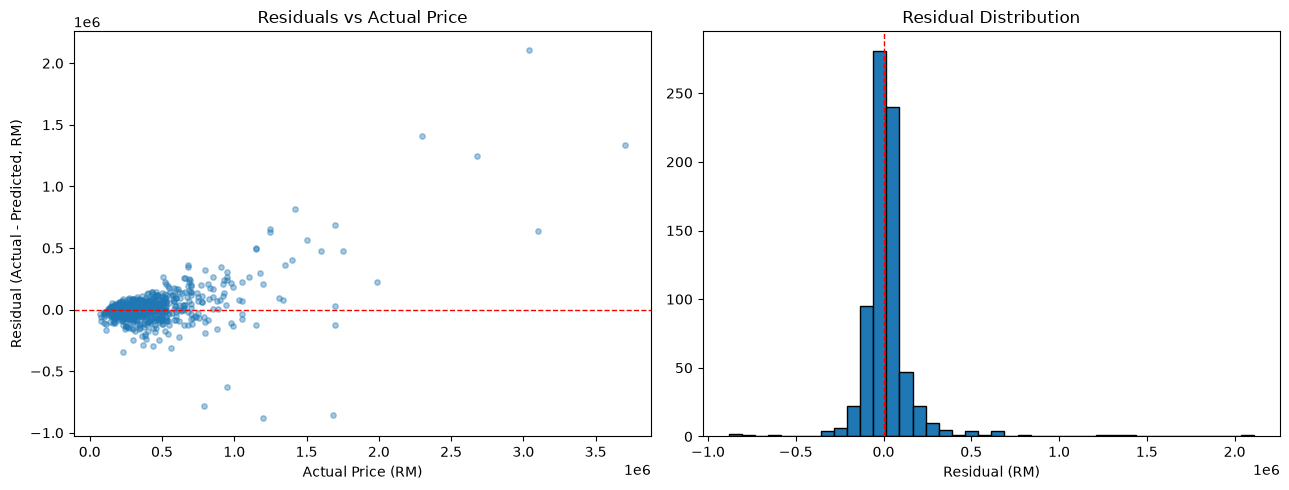

Mean residual (bias): RM 20,019
Residual std:         RM 169,441


,actual_rm,predicted_rm,abs_error_rm
685,3039000.0,9.298989e+05,2.109101e+06
727,2300000.0,8.889301e+05,1.411070e+06
150,3701000.0,2.362133e+06,1.338867e+06
350,2680000.0,1.435878e+06,1.244122e+06
56,1200000.0,2.080664e+06,8.806643e+05
438,1680000.0,2.533701e+06,8.537007e+05
108,1420000.0,6.005402e+05,8.194598e+05
617,790000.0,1.571549e+06,7.815491e+05
400,1700000.0,1.012954e+06,6.870457e+05
474,1250000.0,5.957867e+05,6.542133e+05


In [34]:
import matplotlib.pyplot as plt

test_preds_log = model.predict(X_test)
test_preds_rm = np.exp(test_preds_log)
test_actual_rm = np.exp(y_test)
residuals_rm = test_actual_rm - test_preds_rm

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Residuals vs actual price — spot whether errors grow with price
axes[0].scatter(test_actual_rm, residuals_rm, alpha=0.4, s=15)
axes[0].axhline(0, color="red", linestyle="--", linewidth=1)
axes[0].set_xlabel("Actual Price (RM)")
axes[0].set_ylabel("Residual (Actual - Predicted, RM)")
axes[0].set_title("Residuals vs Actual Price")

# Distribution of residuals — spot skew / bias
axes[1].hist(residuals_rm, bins=40, edgecolor="black")
axes[1].axvline(0, color="red", linestyle="--", linewidth=1)
axes[1].set_xlabel("Residual (RM)")
axes[1].set_title("Residual Distribution")

plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, "xgboost_residuals.png"), dpi=150)
plt.show()

print(f"Mean residual (bias): RM {residuals_rm.mean():,.0f}")
print(f"Residual std:         RM {residuals_rm.std():,.0f}")

# Worst 10 predictions by absolute error — useful to eyeball for data issues / outlier listings
worst = pd.DataFrame({
    "actual_rm": test_actual_rm.values,
    "predicted_rm": test_preds_rm,
    "abs_error_rm": residuals_rm.abs().values,
}).sort_values("abs_error_rm", ascending=False).head(10)
worst

### Sanity Check: Log-Price Transform

In [35]:
print("y_test head (log-price):", y_test.head())
print("y_test dtype:", y_test.dtype)
print("Expected actual price (RM):", np.exp(y_test.iloc[0]))

y_test head (log-price): 0    12.873902
1    12.100712
2    12.089539
3    12.793859
4    12.206073
Name: price, dtype: float64
y_test dtype: float64
Expected actual price (RM): 389999.99999999924


### Environment / Package Versions

For reproducibility — pin these in `requirements.txt` if not already.

In [36]:
import pandas; pandas.__version__

'3.0.3'

In [37]:
import numpy; numpy.__version__

'2.5.0'

In [38]:
import matplotlib; matplotlib.__version__

'3.11.0'

In [39]:
import seaborn; seaborn.__version__

'0.13.2'

In [40]:
import joblib; joblib.__version__

'1.5.3'

In [41]:
import streamlit; streamlit.__version__

'1.59.2'